# Linear Regression

---

## 1. The Model

Linear regression assumes the target $y$ is a **linear combination** of the input features $x \in \mathbb{R}^p$, plus noise:

$$y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p + \varepsilon$$

In matrix form, with $X \in \mathbb{R}^{n \times (p+1)}$ (a column of 1s prepended for the bias):

$$\hat{y} = X\theta$$

| Symbol | Meaning |
|--------|---------|
| $n$ | Number of samples |
| $p$ | Number of features |
| $\theta \in \mathbb{R}^{p+1}$ | Weight vector (includes bias $\theta_0$) |
| $\hat{y} \in \mathbb{R}^n$ | Predicted values |
| $\varepsilon$ | Irreducible noise — assumed $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ |

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'text.color':       '#eee',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.8,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'

import os; os.makedirs('img', exist_ok=True)

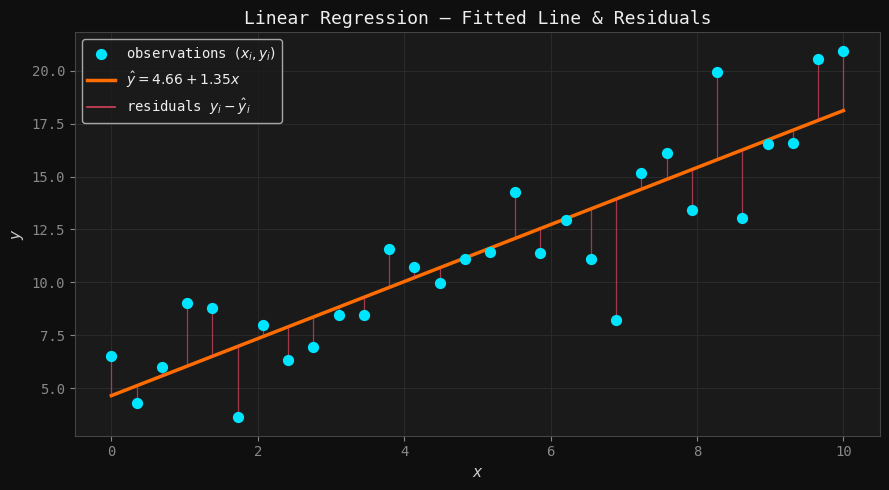

In [8]:
# --- The fitted line + residuals ---
np.random.seed(0)
x = np.linspace(0, 10, 30)
y_true = 1.5 * x + 3
y = y_true + np.random.normal(0, 2, len(x))

# Fit via numpy
X_mat = np.column_stack([np.ones_like(x), x])
theta_hat = np.linalg.lstsq(X_mat, y, rcond=None)[0]
y_hat = X_mat @ theta_hat

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, color=ACCENT, s=50, zorder=5, label='observations $(x_i, y_i)$')
ax.plot(x, y_hat, color=ORANGE, lw=2.5, label=f'$\\hat{{y}} = {theta_hat[0]:.2f} + {theta_hat[1]:.2f}x$')

# Residuals
for xi, yi, yhi in zip(x, y, y_hat):
    ax.plot([xi, xi], [yi, yhi], color=RED, lw=0.9, alpha=0.6)
ax.plot([], [], color=RED, lw=1.2, alpha=0.8, label='residuals $y_i - \\hat{y}_i$')

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Linear Regression — Fitted Line & Residuals')
ax.legend(fontsize=10); ax.grid(True)
plt.tight_layout()
plt.savefig('img/01_fitted_line.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. The Loss Function — Mean Squared Error

We want $\hat{y}$ to be as close as possible to $y$. The natural measure: the **Mean Squared Error (MSE)**:

$$\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \|y - X\theta\|^2$$

**Why squared and not absolute?**
- Squaring penalizes large errors disproportionately — desirable in most cases
- Differentiable everywhere → gradient always exists
- Convex in $\theta$ → unique global minimum guaranteed

**Probabilistic justification** — MSE is actually the **Maximum Likelihood Estimate (MLE)** under the Gaussian noise assumption $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. The log-likelihood is:

$$\log p(y | X, \theta) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\|y - X\theta\|^2$$

Maximizing this is equivalent to **minimizing** $\|y - X\theta\|^2$. MSE is not an arbitrary choice — it is the right loss if you believe your noise is Gaussian.

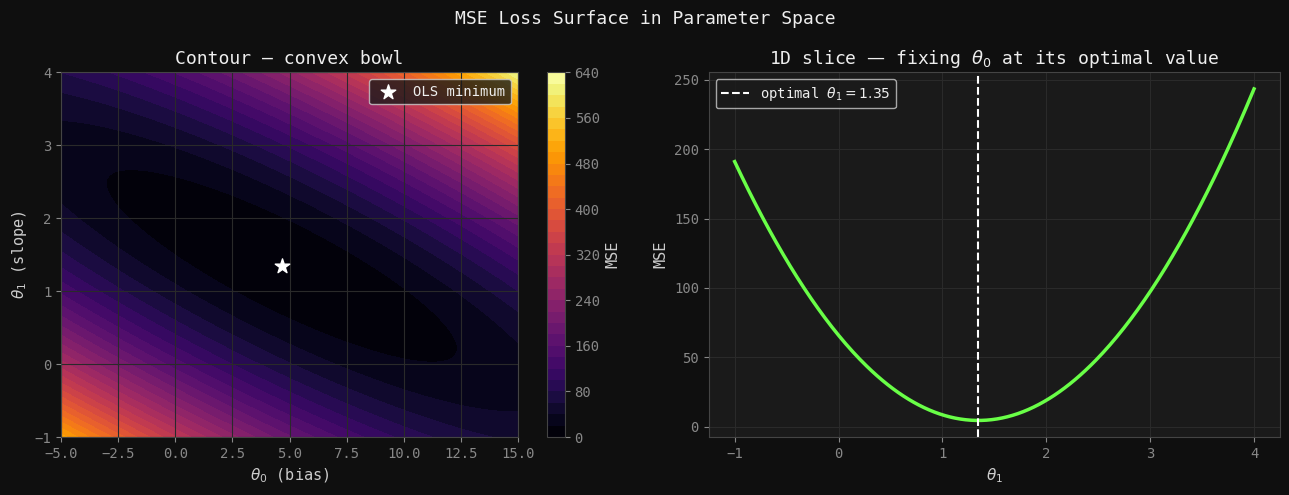

In [9]:
# --- MSE as a convex bowl in (theta_0, theta_1) space ---
t0_range = np.linspace(-5, 15, 100)
t1_range = np.linspace(-1, 4, 100)
T0, T1 = np.meshgrid(t0_range, t1_range)

MSE = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        y_pred = T0[i, j] + T1[i, j] * x
        MSE[i, j] = np.mean((y - y_pred)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MSE Loss Surface in Parameter Space', fontsize=13)

# Contour
ax = axes[0]
cp = ax.contourf(T0, T1, MSE, levels=40, cmap='inferno')
plt.colorbar(cp, ax=ax, label='MSE')
ax.scatter(*theta_hat, color='white', s=120, zorder=5, marker='*', label='OLS minimum')
ax.set_xlabel('$\\theta_0$ (bias)'); ax.set_ylabel('$\\theta_1$ (slope)')
ax.set_title('Contour — convex bowl')
ax.legend(fontsize=10); ax.grid(True)

# 1D slice: fixing theta_0, varying theta_1
ax = axes[1]
t1_slice = np.linspace(-1, 4, 300)
mse_slice = [np.mean((y - (theta_hat[0] + t * x))**2) for t in t1_slice]
ax.plot(t1_slice, mse_slice, color=GREEN, lw=2.5)
ax.axvline(theta_hat[1], color='white', lw=1.5, linestyle='--', label=f'optimal $\\theta_1 = {theta_hat[1]:.2f}$')
ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('MSE')
ax.set_title('1D slice — fixing $\\theta_0$ at its optimal value')
ax.legend(fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig('img/02_mse_surface.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The Normal Equation — Exact Analytical Solution

Because MSE is convex and differentiable, we can find the minimum **analytically** by setting the gradient to zero.

$$\nabla_\theta \mathcal{L} = -\frac{2}{n} X^\top (y - X\theta) = 0$$

Solving for $\theta$:

$$X^\top X\, \theta = X^\top y$$

$$\boxed{\hat{\theta} = (X^\top X)^{-1} X^\top y}$$

This is the **Ordinary Least Squares (OLS)** estimator — the closed-form solution.

**Geometric interpretation**: $\hat{y} = X\hat{\theta}$ is the **orthogonal projection** of $y$ onto the column space of $X$. The residual $y - \hat{y}$ is perpendicular to every column of $X$:

$$X^\top(y - X\hat{\theta}) = 0$$

**When does $(X^\top X)^{-1}$ not exist?**
- Features are **perfectly collinear** (one column is a linear combination of others)
- More features than samples: $p > n$

Fix: use the **Moore-Penrose pseudoinverse** $X^+$, or add regularization (→ Ridge).

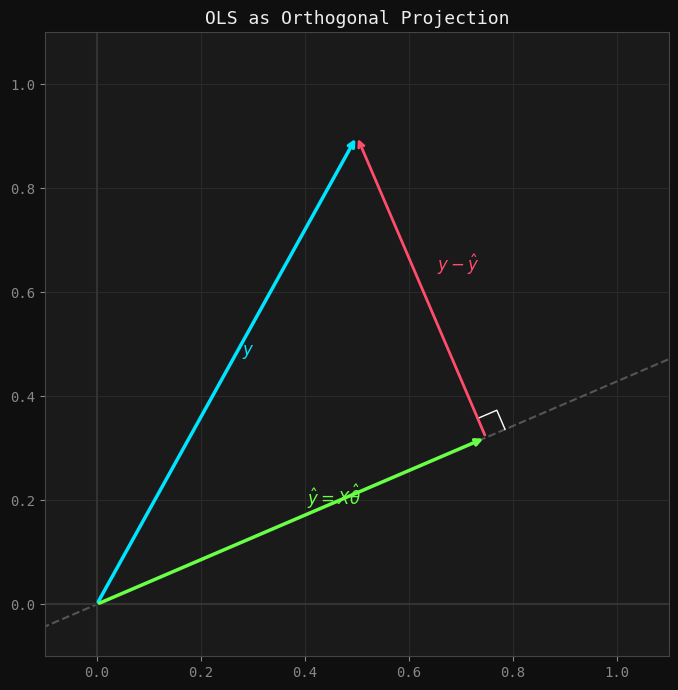

In [10]:
# --- Geometric interpretation: projection onto column space ---
# Simplified 2D illustration: y in R^2, X has 1 column (1D subspace)
fig, ax = plt.subplots(figsize=(7, 7))

# Column space direction
col_dir = np.array([0.7, 0.3])
col_dir /= np.linalg.norm(col_dir)

# True y vector
y_vec = np.array([0.5, 0.9])

# Projection: y_hat = (y . col_dir) * col_dir
y_hat_vec = np.dot(y_vec, col_dir) * col_dir
residual = y_vec - y_hat_vec

origin = np.zeros(2)

# Column space line
scale = np.linspace(-0.2, 1.4, 100)
ax.plot(scale * col_dir[0], scale * col_dir[1], color='#555', lw=1.5, linestyle='--')
ax.annotate('col$(X)$', xy=1.3*col_dir, color='#888', fontsize=11)

# Vectors
def draw_arrow(ax, start, end, color, label='', lw=2):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mid = (start + end) / 2
        ax.text(mid[0]+0.03, mid[1]+0.03, label, color=color, fontsize=12)

draw_arrow(ax, origin, y_vec,     ACCENT, '$y$',         lw=2.5)
draw_arrow(ax, origin, y_hat_vec, GREEN,  '$\\hat{y} = X\\hat{\\theta}$', lw=2.5)
draw_arrow(ax, y_hat_vec, y_vec,  RED,    '$y - \\hat{y}$', lw=2)

# Right angle marker
eps = 0.04
perp_dir = residual / np.linalg.norm(residual) * eps
along_dir = col_dir * eps
corner = y_hat_vec + perp_dir + along_dir
ax.plot([y_hat_vec[0]+along_dir[0], corner[0], y_hat_vec[0]+perp_dir[0]],
        [y_hat_vec[1]+along_dir[1], corner[1], y_hat_vec[1]+perp_dir[1]],
        color='white', lw=1)

ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.set_title('OLS as Orthogonal Projection')
ax.grid(True); ax.axhline(0, color='#333'); ax.axvline(0, color='#333')
plt.tight_layout()
plt.savefig('img/03_projection.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Normal Equation vs Gradient Descent

Both find the same $\hat{\theta}$ — they are two routes to the same minimum.

| | Normal Equation | Gradient Descent |
|---|---|---|
| **Solution** | Exact, one shot | Iterative approximation |
| **Complexity** | $\mathcal{O}(p^3)$ — matrix inversion | $\mathcal{O}(n \cdot p)$ per step |
| **Scales with $n$** | Yes, fine | Very well |
| **Scales with $p$** | Breaks down for large $p$ | Handles large $p$ |
| **Requires tuning** | None | Learning rate $\eta$ |
| **Generalizes to NNs** | No | Yes |

**Rule of thumb**: use the Normal Equation when $p \lesssim 10{,}000$. Beyond that, gradient descent.

## 5. Gauss-Markov Theorem — Why OLS Is Optimal

Under the assumptions:
1. $\mathbb{E}[\varepsilon] = 0$ — zero-mean noise
2. $\text{Var}(\varepsilon) = \sigma^2 I$ — homoscedastic, uncorrelated errors
3. $X$ is fixed (non-random) and full rank

The **Gauss-Markov theorem** states: the OLS estimator $\hat{\theta}$ is the **Best Linear Unbiased Estimator (BLUE)** — it has the smallest variance among all linear unbiased estimators.

The covariance of $\hat{\theta}$ is:

$$\text{Cov}(\hat{\theta}) = \sigma^2 (X^\top X)^{-1}$$

This tells you: features that are nearly collinear make $(X^\top X)$ nearly singular → large diagonal entries → **high variance** on the corresponding coefficients. This is the mathematical root of the multicollinearity problem.

## 6. Regularization — Ridge & Lasso

When features are correlated or $p$ is large, OLS overfits. We add a penalty on $\theta$ to the loss.

### Ridge (L2)

$$\mathcal{L}_{\text{ridge}}(\theta) = \|y - X\theta\|^2 + \lambda \|\theta\|^2$$

Closed-form solution still exists:

$$\hat{\theta}_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top y$$

Adding $\lambda I$ makes the matrix invertible even when $X^\top X$ is singular — Ridge always has a unique solution.

### Lasso (L1)

$$\mathcal{L}_{\text{lasso}}(\theta) = \|y - X\theta\|^2 + \lambda \|\theta\|_1$$

No closed form (L1 is not differentiable at 0), but the key property: **Lasso drives coefficients to exactly zero** → automatic feature selection.

**Why does L1 produce sparsity but L2 doesn't?** It comes down to the geometry of the constraint regions.

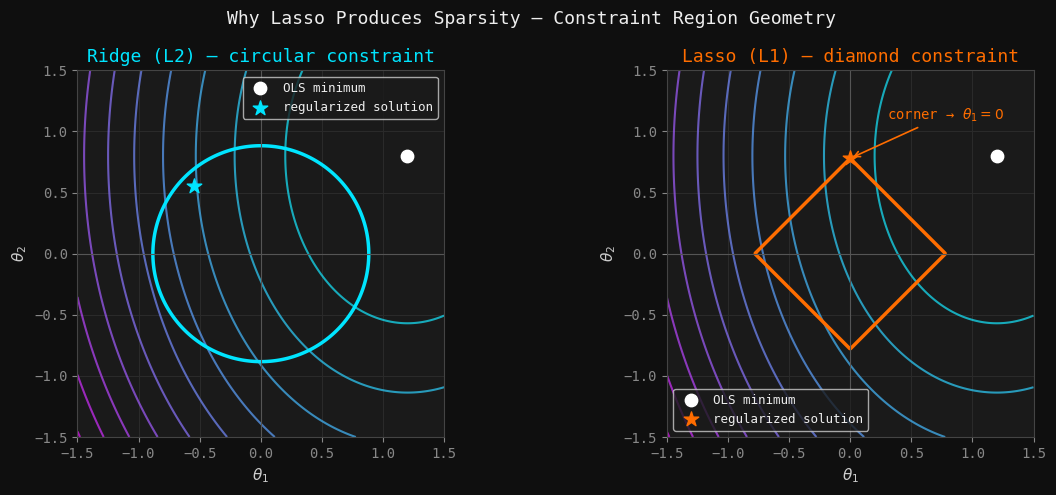

In [11]:
# --- L1 vs L2 constraint geometry ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Why Lasso Produces Sparsity — Constraint Region Geometry', fontsize=13)

theta = np.linspace(-1.5, 1.5, 400)
T0g, T1g = np.meshgrid(theta, theta)

# Elliptical MSE contours centered away from origin
center = np.array([1.2, 0.8])
loss_contour = 1.5*(T0g - center[0])**2 + 0.8*(T1g - center[1])**2

for ax, title, color, shape_fn, intersect in [
    (axes[0], 'Ridge (L2) — circular constraint', ACCENT,
     lambda t0, t1: t0**2 + t1**2, [-.55, .55]),
    (axes[1], 'Lasso (L1) — diamond constraint', ORANGE,
     lambda t0, t1: np.abs(t0) + np.abs(t1), [0, .78]),
]:
    ax.contour(T0g, T1g, loss_contour, levels=12, cmap='cool', alpha=0.7)
    constraint = shape_fn(T0g, T1g)
    ax.contour(T0g, T1g, constraint, levels=[0.78], colors=[color], linewidths=2.5)
    ax.scatter(*center, color='white', s=80, zorder=5, label='OLS minimum')
    ax.scatter(*intersect, color=color, s=120, zorder=6, marker='*',
               label='regularized solution')
    ax.axhline(0, color='#555', lw=0.8); ax.axvline(0, color='#555', lw=0.8)
    ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('$\\theta_2$')
    ax.set_title(title, color=color)
    ax.legend(fontsize=9); ax.grid(True)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')

# Annotation: Lasso hits the corner → sparsity
axes[1].annotate('corner → $\\theta_1 = 0$', xy=(0, 0.78), xytext=(0.3, 1.1),
                 color=ORANGE, fontsize=10,
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))

plt.tight_layout()
plt.savefig('img/04_l1_l2_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

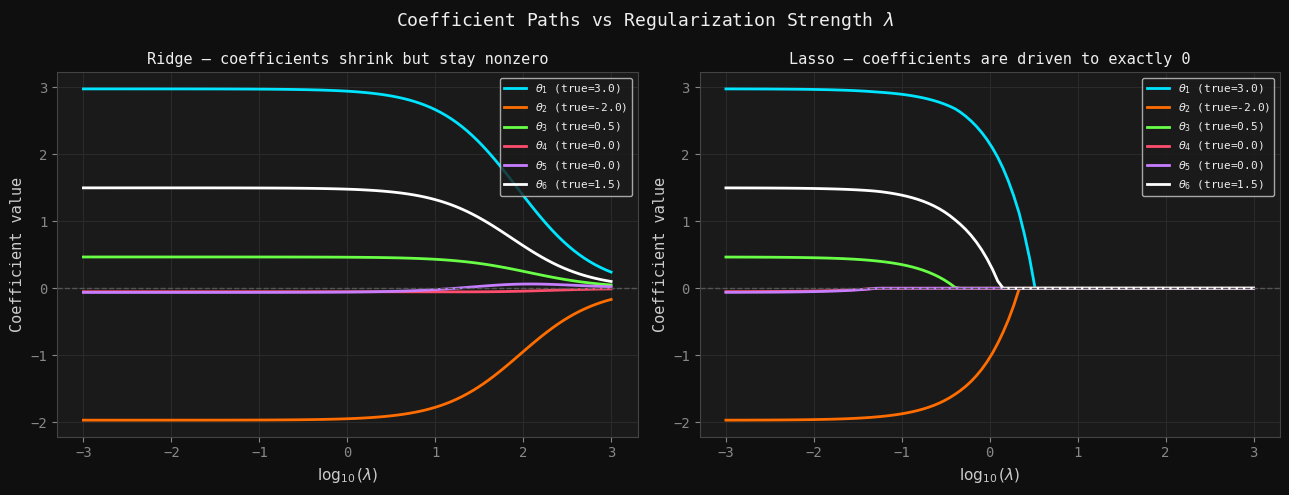

In [14]:
# --- Coefficient paths as lambda increases ---
from sklearn.linear_model import Ridge, Lasso

np.random.seed(1)
n, p = 80, 6
X_reg = np.random.randn(n, p)
true_coef = np.array([3.0, -2.0, 0.5, 0.0, 0.0, 1.5])
y_reg = X_reg @ true_coef + np.random.randn(n) * 0.5

alphas = np.logspace(-3, 3, 100)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_reg, y_reg).coef_ for a in alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=5000).fit(X_reg, y_reg).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Coefficient Paths vs Regularization Strength $\\lambda$', fontsize=13)
colors = [ACCENT, ORANGE, GREEN, RED, PURPLE, '#fff']

for ax, coefs, title in [
    (axes[0], ridge_coefs, 'Ridge — coefficients shrink but stay nonzero'),
    (axes[1], lasso_coefs, 'Lasso — coefficients are driven to exactly 0'),
]:
    for i in range(p):
        ax.plot(np.log10(alphas), coefs[:, i], color=colors[i], lw=2,
                label=f'$\\theta_{i+1}$ (true={true_coef[i]})')
    ax.axhline(0, color='#555', lw=1, linestyle='--')
    ax.set_xlabel('$\\log_{10}(\\lambda)$'); ax.set_ylabel('Coefficient value')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc='upper right'); ax.grid(True)

plt.tight_layout()
plt.savefig('img/05_coef_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation Metrics

### $R^2$ — Coefficient of Determination

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

Interpretation: the fraction of variance in $y$ **explained** by the model.
- $R^2 = 1$ → perfect fit
- $R^2 = 0$ → model is no better than predicting $\bar{y}$ everywhere
- $R^2 < 0$ → model is worse than the mean baseline (possible on test set)

**Warning**: $R^2$ always increases when you add features — even noise. Use **adjusted $R^2$** when comparing models with different $p$:

$$\bar{R}^2 = 1 - (1 - R^2)\frac{n-1}{n-p-1}$$

### RMSE

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_i (y_i - \hat{y}_i)^2}$$

Same unit as $y$ → directly interpretable. Sensitive to outliers (squared errors).

### MAE

$$\text{MAE} = \frac{1}{n}\sum_i |y_i - \hat{y}_i|$$

Also in units of $y$, but more robust to outliers. Corresponds to fitting under L1 loss (→ predicts the median, not the mean).

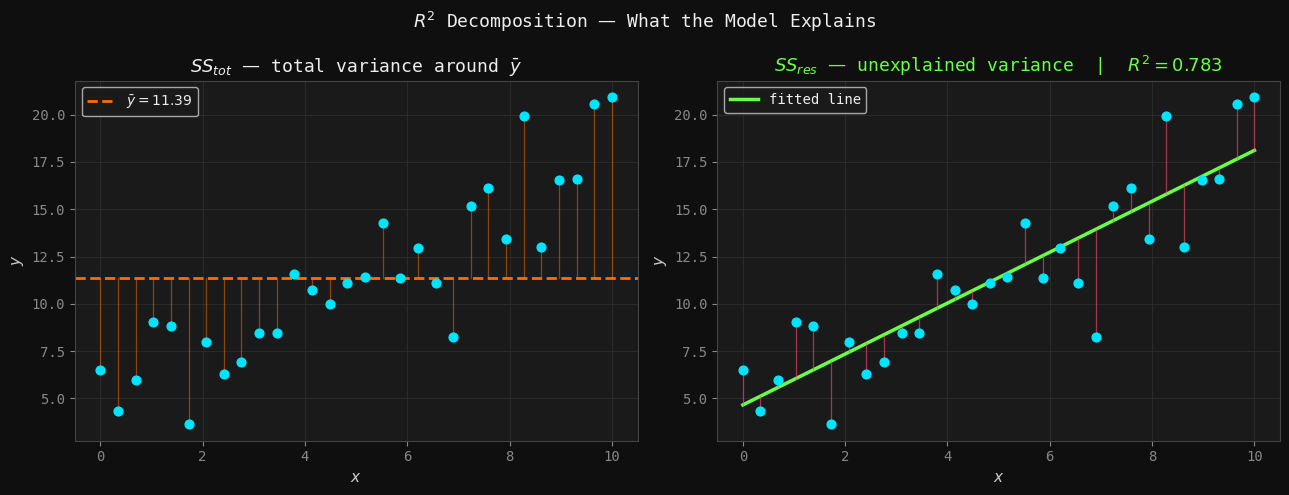

In [15]:
# --- SS_res vs SS_tot visualization ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('$R^2$ Decomposition — What the Model Explains', fontsize=13)

y_mean = np.mean(y)

# SS_tot: variance around the mean
ax = axes[0]
ax.scatter(x, y, color=ACCENT, s=40, zorder=5)
ax.axhline(y_mean, color=ORANGE, lw=2, linestyle='--', label=f'$\\bar{{y}} = {y_mean:.2f}$')
for xi, yi in zip(x, y):
    ax.plot([xi, xi], [yi, y_mean], color=ORANGE, lw=0.9, alpha=0.5)
ax.set_title('$SS_{tot}$ — total variance around $\\bar{y}$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.legend(fontsize=10); ax.grid(True)

# SS_res: residuals around fitted line
ax = axes[1]
ax.scatter(x, y, color=ACCENT, s=40, zorder=5)
ax.plot(x, y_hat, color=GREEN, lw=2.5, label='fitted line')
for xi, yi, yhi in zip(x, y, y_hat):
    ax.plot([xi, xi], [yi, yhi], color=RED, lw=0.9, alpha=0.6)
ss_res = np.sum((y - y_hat)**2)
ss_tot = np.sum((y - y_mean)**2)
r2 = 1 - ss_res / ss_tot
ax.set_title(f'$SS_{{res}}$ — unexplained variance  |  $R^2 = {r2:.3f}$', color=GREEN)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.legend(fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig('img/06_r2.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Bias-Variance Tradeoff

The expected test error of any model can be decomposed as:

$$\mathbb{E}[(y - \hat{y})^2] = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

- **Bias** = error from wrong assumptions — a linear model on non-linear data has high bias
- **Variance** = sensitivity to fluctuations in the training set — a high-degree polynomial has high variance
- **$\sigma^2$** = noise in the data itself — no model can do better than this

Regularization (Ridge/Lasso) deliberately **increases bias** to **reduce variance** — the tradeoff is worth it when overfitting dominates.

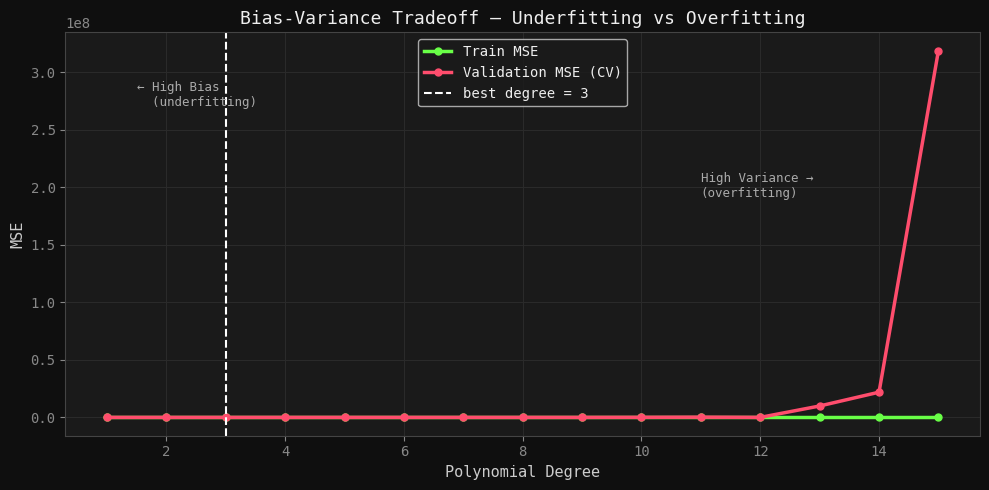

In [16]:
# --- Bias-variance tradeoff across polynomial degrees ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

np.random.seed(42)
x_bv = np.linspace(0, 1, 60).reshape(-1, 1)
y_bv = np.sin(2 * np.pi * x_bv).ravel() + np.random.normal(0, 0.3, 60)

degrees = range(1, 16)
train_errors, val_errors = [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    tr = -cross_val_score(model, x_bv, y_bv, cv=5, scoring='neg_mean_squared_error',
                          error_score='raise')
    model.fit(x_bv, y_bv)
    train_pred = model.predict(x_bv)
    train_errors.append(np.mean((y_bv - train_pred)**2))
    val_errors.append(np.mean(tr))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(degrees), train_errors, color=GREEN,  lw=2.5, marker='o', ms=5, label='Train MSE')
ax.plot(list(degrees), val_errors,   color=RED,    lw=2.5, marker='o', ms=5, label='Validation MSE (CV)')
ax.axvline(list(degrees)[np.argmin(val_errors)], color='white', lw=1.5, linestyle='--',
           label=f'best degree = {list(degrees)[np.argmin(val_errors)]}')
ax.set_xlabel('Polynomial Degree'); ax.set_ylabel('MSE')
ax.set_title('Bias-Variance Tradeoff — Underfitting vs Overfitting')

# Annotations
ax.text(1.5, max(val_errors)*0.85, '← High Bias\n  (underfitting)', color='#aaa', fontsize=9)
ax.text(11, max(val_errors)*0.6,  'High Variance →\n(overfitting)', color='#aaa', fontsize=9)

ax.legend(fontsize=10); ax.grid(True)
plt.tight_layout()
plt.savefig('img/07_bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Takeaways

1. Linear regression minimizes MSE — a **convex loss** with a unique global minimum.
2. The **Normal Equation** gives the exact solution in one shot but costs $\mathcal{O}(p^3)$. For large $p$, use gradient descent.
3. OLS is geometrically an **orthogonal projection** of $y$ onto the column space of $X$.
4. OLS is the **MLE** under Gaussian noise — minimizing squared error is not arbitrary.
5. **Ridge** shrinks coefficients smoothly. **Lasso** zeros them out — the geometry of L1 vs L2 constraints explains why.
6. $R^2$ measures explained variance — always check it on the **test set**, and use adjusted $R^2$ when comparing models of different complexity.
7. The **bias-variance tradeoff** is the fundamental tension in model selection — regularization trades bias for variance.

---